# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import glob
import graphical_sampling as gs
import pandas as pd
import numpy as np
import itertools
from tqdm import tqdm
from package_sampling.utils import inclusion_probabilities

/Users/mehdi/Documents/Projects/graphical_sampling/.venv/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "XPC_SERVICE_NAME" redefined by R and overriding existing variable. Current: "application.com.jetbrains.pycharm.1003326.4172874", R: "0"
  warnings.warn(
/Users/mehdi/Documents/Projects/graphical_sampling/.venv/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_SESSION_TMPDIR" redefined by R and overriding existing variable. Current: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//RtmpuZEZpc", R: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//RtmpumIxHR"
  warnings.warn(


# Loading and Determining Population

In [8]:
DATA_DIR = "populations"
csv_paths = glob.glob(os.path.join(DATA_DIR, "*.csv"))

coords_dict = {}
probs_dict = {}

for fp in csv_paths:
    name = os.path.splitext(os.path.basename(fp))[0]
    data = np.loadtxt(fp, delimiter=",", skiprows=1)
    coords = data[:, :2]
    probs  = data[:, -1]

    coord_name, prob_name, *rest = name.split("_")
    coord_name = 'cluster' if coord_name == 'clust' else coord_name
    prob_name = 'equal' if prob_name == 'eq' else 'unequal'

    coords_dict[coord_name] = coords
    probs_dict[coord_name] = probs_dict.get(coord_name, {})
    probs_dict[coord_name][prob_name] = probs

print(coords_dict.keys())
print(probs_dict.keys())
print(probs_dict['random'].keys())

dict_keys(['swiss', 'RegularPop1000', 'cluster', 'meuse', 'random', 'grid', 'AggregatedPop1027'])
dict_keys(['swiss', 'RegularPop1000', 'cluster', 'meuse', 'random', 'grid', 'AggregatedPop1027'])
dict_keys(['equal', 'unequal'])


In [246]:
N = 100
n = 4
pop_str = 'grid'
prob_str = 'equal'
coords = coords_dict[pop_str]
probs = probs_dict[pop_str][prob_str]
modified_probs = inclusion_probabilities(probs, n=n)
pop = gs.Population(coords, modified_probs)

In [229]:
coords = np.loadtxt("populations/AggregatedPop1027_2d.csv", delimiter=",", skiprows=0)
# coords = np.loadtxt("populations/RegularPop1000_2d.csv", delimiter=",", skiprows=0)
rng = gs.random.rng()
n = 100
probs = rng.equal_probabilities(n, coords.shape[0])
pop = gs.Population(coords, probs)

# Test

In [252]:
ks = gs.sampling.KMeansSampler(
    population=pop,
    n=n,
    n_clusters=4,
    # cluster_in_cluster=True,
    n_zones=(2, 2),
    zone_builder='sweep',
    units_order='spiral',
    zones_order='spiral',
    split_size=0.001
)

In [216]:
ks.labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [211]:
ks.all_samples.shape

(25, 4)

In [212]:
np.sum(ks.all_samples_probs)

np.float64(1.0)

In [213]:
ks.score_summary_df()

,expected,std
measure,,
density,0.000000,0.000000
moran,-0.456751,0.137355
local_balance,0.411552,0.152782
voronoi,0.166400,0.102328


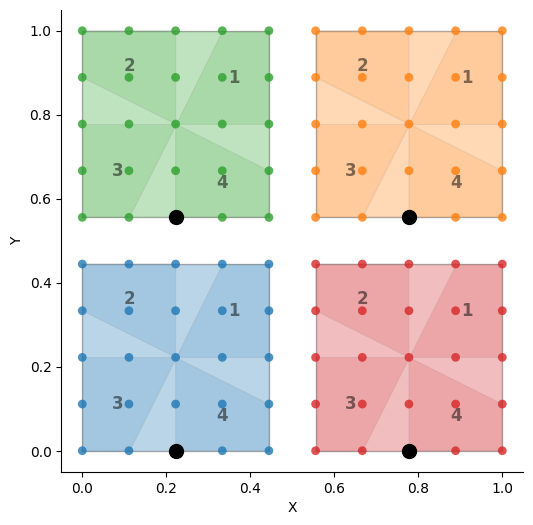

In [253]:
ax = gs.plot(pop, ks.clusters, connect_points=False)
ax.scatter(*pop.coords[ks.all_samples[5]].T, c='black', s=100, zorder=10)

In [180]:
for cluster in ks.clusters:
    cluster_index_share = cluster.get_index_share()
    print(f'\ncluster prob sum: {np.sum(pop.probs[cluster_index_share[:, 0].astype(int)]*cluster_index_share[:, 1])}')
    for zone in cluster.zones:
        print(f'zone prob sum: {np.sum(zone.prob)}')


cluster prob sum: 2.0000000000000004
zone prob sum: 0.5000000000000003
zone prob sum: 0.5000000000000003
zone prob sum: 0.5000000000000001
zone prob sum: 0.5000000000000001

cluster prob sum: 2.0000000000000004
zone prob sum: 0.5000000000000003
zone prob sum: 0.5000000000000003
zone prob sum: 0.5000000000000001
zone prob sum: 0.5000000000000001


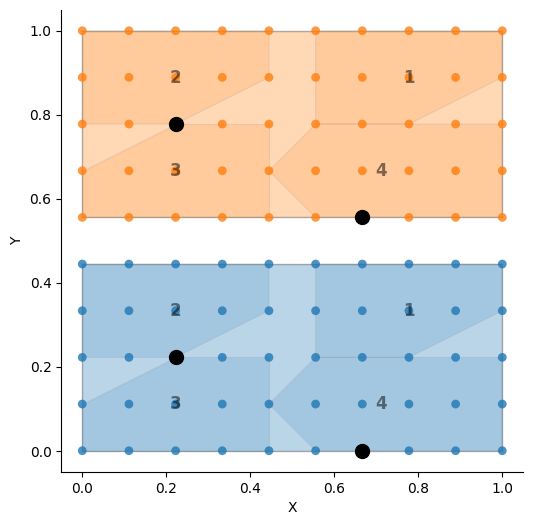

In [99]:
samples = ks.sample(10)
ax = gs.plot(pop, ks.clusters, connect_points=False)
ax.scatter(*pop.coords[samples[0]].T, c='black', s=100, zorder=10)

# Building Initial Designs

In [230]:
orders = [
    # "lexico-yx",
    # "lexico-xy",
    # "random",
    # "angle_0",
    # "distance_0",
    # "projection",
    # "center",
    "spiral",
    # "max",
    # "snake",
    # "hilbert",
]
n_zones_sweep = [(2, 2)]
n_zones_cluster = [4, 6]
combinations = list(itertools.product(['sweep'], n_zones_sweep, orders, orders)) #+ list(itertools.product(['cluster'], n_zones_cluster, orders, orders))

In [231]:
initial_designs = []
num_trials = 1
for zone_builder, n_zones, units_order, zones_order in tqdm(combinations, desc="Generating initial designs", total=len(combinations), unit="orders"):
    best = None
    best_score = np.inf
    for _ in range(num_trials):
        ks = gs.sampling.KMeansSampler(
            population=pop,
            n = n,
            n_clusters=20,
            # n=(2, 2, 5),
            # cluster_in_cluster=True,
            n_zones=n_zones,
            zone_builder=zone_builder,
            units_order=units_order,
            zones_order=zones_order,
            split_size=0.001
        )
        if ks.expected_moran_score() < best_score:
            best = ks
            best_score = ks.expected_moran_score()

    initial_designs.append(gs.NewDesign(best))

Generating initial designs:   0%|          | 0/1 [00:00<?, ?orders/s]/Users/mehdi/Documents/Projects/graphical_sampling/.venv/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_SESSION_TMPDIR" redefined by R and overriding existing variable. Current: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//RtmpumIxHR", R: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//RtmpVb1Oga"
  warnings.warn(
/Users/mehdi/Documents/Projects/graphical_sampling/.venv/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_SESSION_TMPDIR" redefined by R and overriding existing variable. Current: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//RtmpumIxHR", R: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//Rtmpcyj7Dg"
  warnings.warn(
/Users/mehdi/Documents/Projects/graphical_sampling/.venv/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_SESSION_TMPDIR" re

# Run

In [232]:
moran_criteria = gs.criteria.MoranCriteria()
moran_with_penalty = gs.criteria.MoranWithPenaltyCriteria()

In [233]:
initial_criteria_value = np.array([moran_criteria(design) for design in initial_designs])
best_design = initial_designs[np.argmax(initial_criteria_value)]
best_criteria_value = np.min(initial_criteria_value)
best_criteria_value

np.float64(-0.1549363578212474)

In [235]:
astar = gs.search.AStar(
    initial_designs,
    moran_criteria
)

best initial criteria value -0.1549363578212474


In [11]:
astar = gs.search.AStar(
    [astar.best_design],
    moran_criteria
)

best initial criteria value -0.3516009455861876


In [19]:
astar.run(
    max_iterations = 1000,
    num_new_nodes = 20,
    max_open_set_size = 1000,

    n_clusters_to_change_order_zone = 1,
    n_changes_in_order_of_zones = 1,

    n_clusters_to_change_order_units = 1,
    n_zones_to_change_order_units = 1,
    n_changes_in_order_of_units = 1,

    n_jobs=-1
)


parent node: 0.29312609813177565


/Users/mehdi/Documents/Projects/graphical_sampling/.venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/mehdi/Documents/Projects/graphical_sampling/.venv/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_SESSION_TMPDIR" redefined by R and overriding existing variable. Current: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//RtmpUvEwc5", R: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//RtmpuIay4z"
  warnings.warn(
/Users/mehdi/Documents/Projects/graphical_sampling/.venv/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_SESSION_TMPDIR" redefined by R and overriding existing variable. Current: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//RtmpuIay4z", R: "/var/folders/tw/x1njhbdj7q19p

child node: 0.2932184359184181
child node: 0.29323906725537163
child node: 0.2931907019115013
child node: 0.29297965972212875

New best criteria value: 0.29297965972212875
child node: 0.2922614803770843

New best criteria value: 0.2922614803770843
child node: 0.2931327600989549
child node: 0.2939646109237721
child node: 0.29433602896617195
child node: 0.29215930698649906

New best criteria value: 0.29215930698649906
child node: 0.29443257687599445
child node: 0.29308708039846393
child node: 0.2927411041439756
child node: 0.29241458337566567
child node: 0.2931798155835299
child node: 0.2931139898618942
child node: 0.2936453588388784
child node: 0.29517678472106446

parent node: 0.29215930698649906


/Users/mehdi/Documents/Projects/graphical_sampling/.venv/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_SESSION_TMPDIR" redefined by R and overriding existing variable. Current: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//RtmpUvEwc5", R: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//RtmpNlsrKr"
  warnings.warn(
/Users/mehdi/Documents/Projects/graphical_sampling/.venv/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_SESSION_TMPDIR" redefined by R and overriding existing variable. Current: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//RtmpNlsrKr", R: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//RtmpmQ9pAJ"
  warnings.warn(
/Users/mehdi/Documents/Projects/graphical_sampling/.venv/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_SESSION_TMPDIR" redefined by R and overriding existing variable. Current: "/var/folders

child node: 0.2919947402174875

New best criteria value: 0.2919947402174875
child node: 0.29215930698649906
child node: 0.3045518891187861
child node: 0.2923258772672059
child node: 0.2927120187746698
child node: 0.2924120323962477
child node: 0.41217799466483485
child node: 0.29198699470217765

New best criteria value: 0.29198699470217765
child node: 0.29431403447033155
child node: 0.2926236799958768
child node: 0.2915650276304543

New best criteria value: 0.2915650276304543
child node: 0.2921777987930313
child node: 0.2899091896381392

New best criteria value: 0.2899091896381392
child node: 0.2912574273015705
child node: 0.5626984302694187
child node: 0.293695860815968
child node: 0.2926409241544099

parent node: 0.2899091896381392
child node: 0.2891345212895254

New best criteria value: 0.2891345212895254
child node: 0.29000112113581333
child node: 0.28953716156551945
child node: 0.28998176638257933
child node: 0.28995582088883287
child node: 0.28988714118414977
child node: 0.288559

KeyboardInterrupt: 

In [236]:
astar.best_criteria_value

np.float64(-0.1549363578212474)

In [237]:
astar.best_design.kmeans.expected_moran_score()

-0.1549363578212474

In [238]:
astar.best_design.kmeans.all_samples.shape

(367, 100)

In [239]:
np.sum(astar.best_design.kmeans.all_samples_probs)

np.float64(0.929401017878)

In [27]:
np.mean(np.abs(astar.best_design.kmeans.fips - probs))

np.float64(0.00015559045791857377)

In [240]:
astar.best_design.kmeans.fips

array([0.09737098, 0.09737098, 0.07578876, ..., 0.09460043, 0.09460043,
       0.09737098], shape=(1027,))

In [241]:
astar.best_design.kmeans.all_samples

array([[1024, 1025,  514, ...,  506,  509,  510],
       [ 520,    9,  524, ...,  504, 1019, 1022],
       [   1,   10,  526, ..., 1010, 1013, 1015],
       ...,
       [ 512,    6,  522, ..., 1008, 1018,  509],
       [ 512,    6,  522, ..., 1008, 1018,  509],
       [ 512,    6,  522, ..., 1008, 1018,  509]], shape=(367, 100))

In [243]:
astar.best_design.kmeans.score_summary_df()

,expected,std
measure,,
density,0.046438,0.040861
moran,-0.154936,0.077472
local_balance,0.075351,0.021886
voronoi,0.206322,0.068049


In [244]:
for cluster in astar.best_design.kmeans.clusters:
    cluster_index_share = cluster.get_index_share()
    print(f'\ncluster prob sum: {np.sum(pop.probs[cluster_index_share[:, 0].astype(int)]*cluster_index_share[:, 1])}')
    for zone in cluster.zones:
        print(f'zone prob sum: {np.sum(zone.prob)}')


cluster prob sum: 5.0000501912285795
zone prob sum: 1.2500125478071458
zone prob sum: 1.2500125478071444
zone prob sum: 1.250012547807145
zone prob sum: 1.250012547807145

cluster prob sum: 5.0000501912285795
zone prob sum: 1.2500125478071462
zone prob sum: 1.2500125478071447
zone prob sum: 1.2500125478071449
zone prob sum: 1.2500125478071449

cluster prob sum: 5.00005019122858
zone prob sum: 1.2500125478071447
zone prob sum: 1.2500125478071449
zone prob sum: 1.2500125478071449
zone prob sum: 1.250012547807146

cluster prob sum: 5.0000501912285795
zone prob sum: 1.2500125478071453
zone prob sum: 1.250012547807145
zone prob sum: 1.250012547807145
zone prob sum: 1.250012547807145

cluster prob sum: 5.0000501912285795
zone prob sum: 1.2500125478071464
zone prob sum: 1.2500125478071444
zone prob sum: 1.2500125478071449
zone prob sum: 1.2500125478071449

cluster prob sum: 5.0000501912285795
zone prob sum: 1.2500125478071449
zone prob sum: 1.2500125478071464
zone prob sum: 1.250012547807144

In [30]:
def info(kmeans):
    mean = round(float(kmeans.expected_moran_score()), 2)
    moran_scores = astar.best_design.kmeans.moran_scores
    median = round(float(np.median(moran_scores)), 2)
    sd = round(float(np.sqrt(kmeans.var_moran_score())), 2)
    min_ = round(float(np.min(moran_scores)), 2)
    max_ = round(float(np.max(moran_scores)), 2)
    return mean, median, sd, min_, max_

In [31]:
info(astar.best_design.kmeans)

(-0.25, -0.25, 0.05, -0.4, -0.14)

<Axes: xlabel='X', ylabel='Y'>

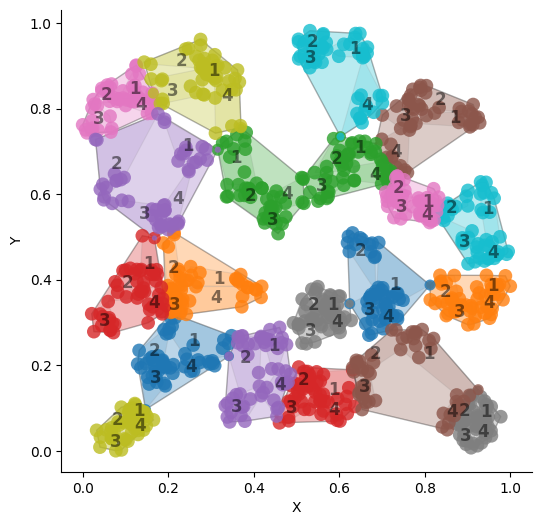

In [245]:
gs.plot(pop, astar.best_design.kmeans.clusters, connect_points=False)

In [6]:
x = [1, 2, 3]
y = []
for i in x:
    y.append(i+5)
x = y[:]

In [7]:
x

[6, 7, 8]